In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('house_price_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100, 8)


,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
0,3774,2,3,28,16.1,1,3,446385
1,4107,4,2,17,23.3,1,3,489543
2,1460,2,3,17,7.3,0,1,185140
3,1894,2,3,1,NaN,1,1,286522
4,1730,4,2,34,3.5,0,2,212784


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area_sqft            100 non-null    int64  
 1   Bedrooms             100 non-null    int64  
 2   Bathrooms            100 non-null    int64  
 3   Age_years            100 non-null    int64  
 4   Distance_to_city_km  97 non-null     float64
 5   Garage               100 non-null    int64  
 6   Floors               100 non-null    int64  
 7   Price_USD            100 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 6.4 KB


In [12]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
count,100.000000,100.000000,100.000000,100.000000,97.000000,100.000000,100.000000,100.000000
mean,2717.380000,2.980000,2.040000,21.440000,14.676289,0.420000,1.890000,328377.300000
std,1104.021197,1.476961,0.839913,11.001671,8.517332,0.496045,0.827495,134402.974694
min,621.000000,1.000000,1.000000,0.000000,1.400000,0.000000,1.000000,55418.000000
25%,1807.250000,1.750000,1.000000,14.000000,6.700000,0.000000,1.000000,210127.250000
50%,2791.500000,3.000000,2.000000,22.500000,14.800000,0.000000,2.000000,332383.500000
75%,3622.000000,4.000000,3.000000,31.000000,21.400000,1.000000,3.000000,439099.250000
max,4493.000000,5.000000,3.000000,39.000000,29.700000,1.000000,3.000000,578851.000000


In [13]:
print(df.isnull().sum())

Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_years              0
Distance_to_city_km    3
Garage                 0
Floors                 0
Price_USD              0
dtype: int64


In [14]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
0,3774,2,3,28,16.1,1,3,446385
1,4107,4,2,17,23.3,1,3,489543
2,1460,2,3,17,7.3,0,1,185140
3,1894,2,3,1,NaN,1,1,286522
4,1730,4,2,34,3.5,0,2,212784


In [16]:
df.fillna(df.mean(), inplace=True)

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
0,3774,2,3,28,16.100000,1,3,446385
1,4107,4,2,17,23.300000,1,3,489543
2,1460,2,3,17,7.300000,0,1,185140
3,1894,2,3,1,14.676289,1,1,286522
4,1730,4,2,34,3.500000,0,2,212784
...,...,...,...,...,...,...,...,...
95,4443,3,3,21,29.700000,0,2,495608
96,4493,3,2,21,13.000000,0,2,556496
97,2100,1,1,5,11.800000,1,2,277020
98,1302,5,3,14,23.500000,1,3,199575


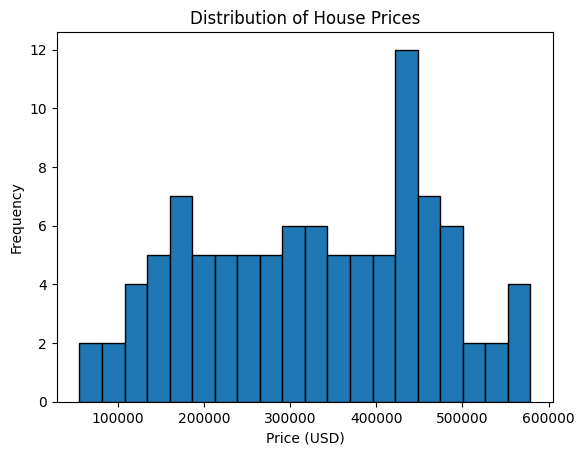

In [17]:
plt.Figure(figsize=(8, 4))
plt.hist(df['Price_USD'], bins=20, edgecolor='k')
plt.title('Distribution of House Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()
 

In [18]:
features = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_to_city_km', 'Garage', 'Floors']
 